In [4]:
try:
    import pandas as pd
except ImportError:
    print("Pandas not installed")
    %pip install pandas --user

try:
    import matplotlib.pyplot as plt
except ImportError:
    print("Matplotlib not installed")
    %pip install matplotlib --user

import ssl

ssl._create_default_https_context = ssl._create_unverified_context

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
archivo = "StreamingHistory_Extended.csv"
spotify : pd.DataFrame = pd.read_csv(archivo)
spotify

C:\Users\50030868\AppData\Local\Temp\ipykernel_7196\4060803231.py:2: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  spotify : pd.DataFrame = pd.read_csv(archivo)


,ts,username,platform,ms_played,conn_country,user_agent_decrypted,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,episode_show_name,spotify_episode_uri,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,is_podcast
0,2020-12-06T02:51:11Z,11145402699,"iOS 14.2 (iPhone12,3)",145610,AR,unknown,Hey Jude - Remastered 2015,The Beatles,1,spotify:track:0aym2LBJBk9DAYuHHutrIl,NaN,NaN,NaN,trackdone,fwdbtn,True,NaN,False,1607222710755,False
1,2020-12-06T02:53:31Z,11145402699,"iOS 14.2 (iPhone12,3)",138692,AR,unknown,Hacer un puente,La Franela,Hacer Un Puente,spotify:track:18Q3WTfyWX1tdS1cp42NhA,NaN,NaN,NaN,fwdbtn,fwdbtn,True,NaN,False,1607223071185,False
2,2020-12-06T02:53:53Z,11145402699,"iOS 14.2 (iPhone12,3)",22662,AR,unknown,Happy Together - Remastered,The Turtles,All the Singles,spotify:track:2admbUc576sC6M0QeUkg2C,NaN,NaN,NaN,fwdbtn,fwdbtn,True,NaN,False,1607223210387,False
3,2020-12-06T02:53:56Z,11145402699,"iOS 14.2 (iPhone12,3)",2716,AR,unknown,Demons,Imagine Dragons,Night Visions,spotify:track:5qaEfEh1AtSdrdrByCP7qR,NaN,NaN,NaN,fwdbtn,fwdbtn,True,NaN,False,1607223233165,False
4,2020-12-06T02:53:57Z,11145402699,"iOS 14.2 (iPhone12,3)",116,AR,unknown,"Paint It, Black",The Rolling Stones,Aftermath,spotify:track:63T7DJ1AFDD6Bn8VzG6JE8,NaN,NaN,NaN,fwdbtn,fwdbtn,True,NaN,False,1607223236453,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125344,2018-10-05T22:44:53Z,11145402699,"iOS 12.0 (iPhone8,1)",1365,AR,unknown,Gente Que No Sabe Lo Que Quiere,Litto Nebbia,Solo Se Trata de Vivir / Solopiano Vol. 1,spotify:track:3u8sP95YHOsYwRQfms6kgc,NaN,NaN,NaN,fwdbtn,fwdbtn,False,NaN,False,1538779491211,False
125345,2018-10-05T22:44:54Z,11145402699,"iOS 12.0 (iPhone8,1)",1344,AR,unknown,11 Y 6,Fito Paez,Giros,spotify:track:2PkTjm1QAJCZbJ9MqC4RqA,NaN,NaN,NaN,fwdbtn,fwdbtn,False,NaN,False,1538779492740,False
125346,2018-10-05T22:44:55Z,11145402699,"iOS 12.0 (iPhone8,1)",832,AR,unknown,Mientes,Charly García,Tango 4,spotify:track:670dXRMKr9vVtGk01dYeSr,NaN,NaN,NaN,fwdbtn,fwdbtn,False,NaN,False,1538779494205,False
125347,2018-10-05T22:44:56Z,11145402699,"iOS 12.0 (iPhone8,1)",1194,AR,unknown,Apostar al Amor,Los Tipitos,Push,spotify:track:6PyBNCpOX5uOjKDNjNNgjq,NaN,NaN,NaN,fwdbtn,fwdbtn,False,NaN,False,1538779495059,False


In [7]:
spotify.columns

Index(['ts', 'username', 'platform', 'ms_played', 'conn_country',
       'user_agent_decrypted', 'master_metadata_track_name',
       'master_metadata_album_artist_name', 'master_metadata_album_album_name',
       'spotify_track_uri', 'episode_name', 'episode_show_name',
       'spotify_episode_uri', 'reason_start', 'reason_end', 'shuffle',
       'skipped', 'offline', 'offline_timestamp', 'is_podcast'],
      dtype='object')

In [8]:
spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125349 entries, 0 to 125348
Data columns (total 20 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   ts                                 125349 non-null  object
 1   username                           125349 non-null  int64 
 2   platform                           125349 non-null  object
 3   ms_played                          125349 non-null  int64 
 4   conn_country                       125349 non-null  object
 5   user_agent_decrypted               104897 non-null  object
 6   master_metadata_track_name         123953 non-null  object
 7   master_metadata_album_artist_name  123953 non-null  object
 8   master_metadata_album_album_name   123953 non-null  object
 9   spotify_track_uri                  123953 non-null  object
 10  episode_name                       168 non-null     object
 11  episode_show_name                  168 non-null     

In [9]:
spotify["ts"] = pd.to_datetime(spotify["ts"])

print("Primera reproducción:", spotify["ts"].min())
print("Última reproducción:", spotify["ts"].max())

# con ts puedo sacar el año, el mes, el día y la hora
# por eso lo uso con min para sacar la primera reproducción y con max para sacar la última reproducción.

Primera reproducción: 2014-06-27 18:01:15+00:00
Última reproducción: 2024-05-23 23:56:20+00:00


In [10]:
canciones = spotify[spotify["is_podcast"] == False]

cant_canciones = (
    canciones["master_metadata_track_name"]
    + canciones["master_metadata_album_artist_name"]
).nunique()

print("Canciones diferentes:", cant_canciones)

# primero si es podcast, no es canción, por eso filro las canciones.
# Cuento cuántas canciones distintas se escucharon.
# uso canción + artista para evitar repetir canciones, con unique cuento las canciones distintas.

Canciones diferentes: 10294


In [11]:
max_reproducion_canciones = canciones["ms_played"].sum()

max_reproducion_canciones_hora = max_reproducion_canciones  / 1000 / 60 / 60

print("Maximo de  tiempo reporducido por hora", max_reproducion_canciones_hora)

# ms_played es el tiempo que se reprodujo la cancion en milisegundos
# por eso lo uso con sum para sacar el tiempo total que se reprodujo la canción 
# lo divido por 1000, 60, 60 para pasarlo a horas.

Maximo de  tiempo reporducido por hora 3466.644294166667


In [12]:
artistas = canciones.groupby("master_metadata_album_artist_name"
)["ms_played"].sum()

artista_mas_escuchado = artistas.idxmax()

print("Artista más escuchado:", artista_mas_escuchado)

# uso gruopby para combinar el artista con el tiempo que se reprodujo la canción
# con sum para sacar el tiempo total que se reprodujo cada artista 
# con idxmax saco el artista que más se reprodujo.


Artista más escuchado: Charly García


In [13]:
canciones_mas = canciones.groupby(
    ["master_metadata_track_name",
     "master_metadata_album_artist_name"]
)["ms_played"].sum()

tema, artista = canciones_mas.idxmax()

print(f"Canción más escuchada: {tema} - {artista}")

# uso groupby para combinar la canción con el artista y el tiempo que se reprodujo la canción, para que no se repitan canciones de distintos artistas que tengan el mismo nombre
# con sum para sacar el tiempo total que se reprodujo cada canción
# con idxmax saco la canción que más se reprodujo.


Canción más escuchada: Redbone - Childish Gambino


In [14]:
Charly = canciones[canciones["master_metadata_album_artist_name"] == artista_mas_escuchado]

tema_de_charly = Charly.groupby("master_metadata_track_name")["ms_played"].sum().idxmax()

print("Canción más escuchada de", artista_mas_escuchado, ":", tema_de_charly)

# filtro las canciones del artista más escuchado
# con groupby combino la canción con el tiempo que se reprodujo la canción
# con sum saco el tiempo total que se reprodujo cada canción 
# con idxmax saco la canción que más se reprodujo del artista más escuchado.

Canción más escuchada de Charly García : Hablando a Tu Corazón


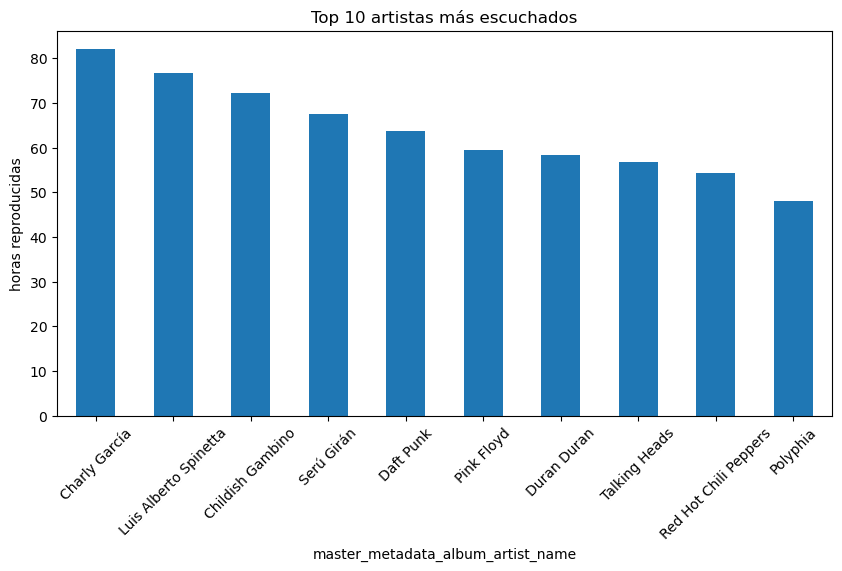

In [15]:
top10_artistas = canciones.groupby("master_metadata_album_artist_name")["ms_played"].sum().sort_values(ascending=False).head(10)

top10_artistas = top10_artistas / (1000 * 60 * 60)


plt.figure(figsize=(10, 5))
top10_artistas.plot(kind="bar")
plt.title("Top 10 artistas más escuchados")
plt.ylabel("horas reproducidas")
plt.xticks(rotation=45)
plt.show()

# con groupby combino el artista con el tiempo que se reprodujo la canción
# con sum saco el tiempo total que se reprodujo cada artista
# con sort_values ordeno de mayor a menor y con head saco los 10 primeros
# lo divido por 1000, 60, 60 para pasarlo a horas

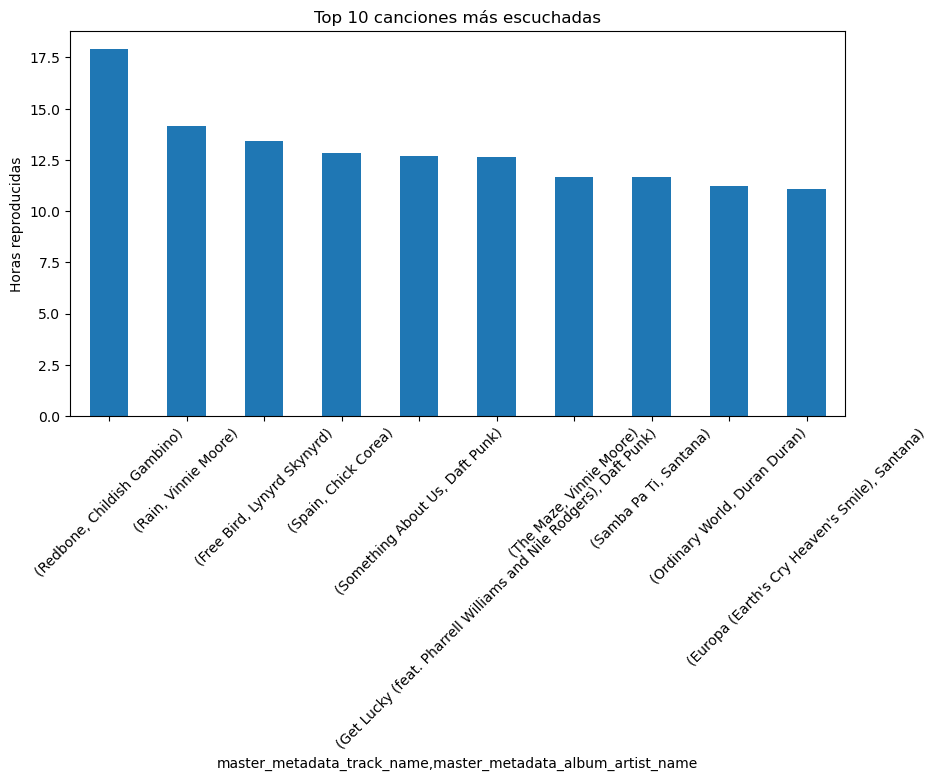

In [16]:
top10_canciones = canciones.groupby(
    ["master_metadata_track_name",
     "master_metadata_album_artist_name"]
)["ms_played"].sum().sort_values(ascending=False).head(10)

top10_canciones = top10_canciones / (1000 * 60 * 60)

plt.figure(figsize=(10,5))
top10_canciones.plot(kind="bar")

plt.title("Top 10 canciones más escuchadas")
plt.ylabel("Horas reproducidas")
plt.xticks(rotation=45)

plt.show()

# con groupby combino la canción con el artista y el tiempo que se reprodujo la canción, para que no se repitan canciones de distintos artistas que tengan el mismo nombre
# con sum para sacar el tiempo total que se reprodujo cada canción
# con sort_values ordeno de mayor a menor y con head saco las 10 primeras
# lo divido por 1000, 60, 60 para pasarlo a horas

C:\Users\50030868\AppData\Local\Temp\ipykernel_7196\3530299312.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  canciones["dia_semana"] = canciones["ts"].dt.day_name()


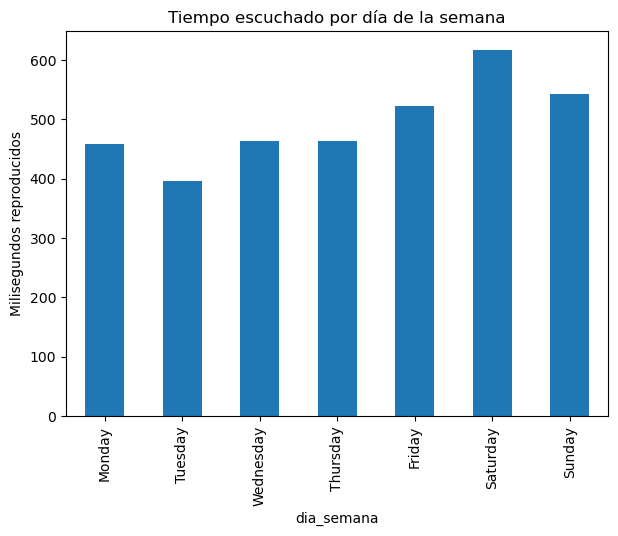

In [17]:
canciones["dia_semana"] = canciones["ts"].dt.day_name()

dias = canciones.groupby("dia_semana")["ms_played"].sum()

orden = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

dias = dias.reindex(orden)

dias = dias / (1000 * 60 * 60)

plt.figure(figsize=(7,5))
dias.plot(kind="bar")

plt.title("Tiempo escuchado por día de la semana")
plt.ylabel("Milisegundos reproducidos")
plt.show()

# con dt.day_name saco el nombre del día de la semana
# con groupby combino el día de la semana con el tiempo que se reprodujo la canción
# con sum saco el tiempo total que se reprodujo cada día de la semana
# con reindex ordeno los días de la semana
# lo divido por 1000, 60, 60 para pasarlo a horas

C:\Users\50030868\AppData\Local\Temp\ipykernel_7196\3761822700.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  canciones["hora"] = canciones["ts"].dt.hour


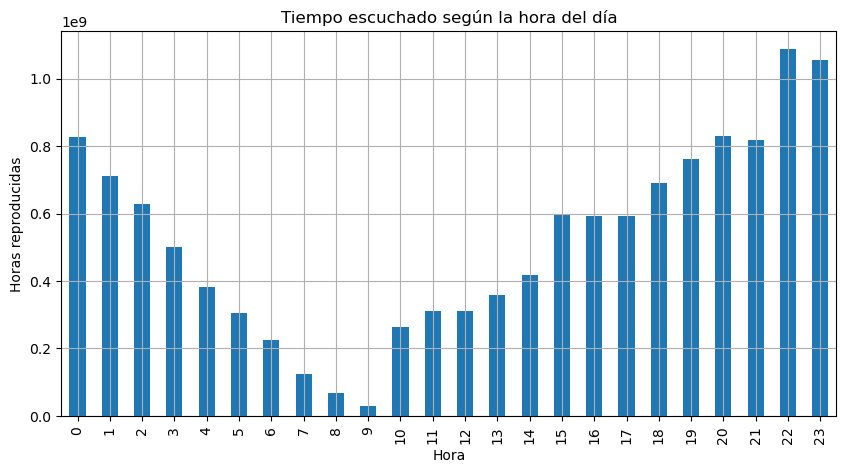

In [18]:
canciones["hora"] = canciones["ts"].dt.hour

horas = canciones.groupby("hora")["ms_played"].sum()

plt.figure(figsize=(10,5))
horas.plot(kind="bar")

horas = horas / (1000 * 60 * 60)

plt.title("Tiempo escuchado según la hora del día")
plt.xlabel("Hora")
plt.ylabel("Horas reproducidas")

plt.grid()
plt.show()

# con dt.hour saco la hora del día
# con groupby combino la hora del día con el tiempo que se reprodujo la canción
# con sum saco el tiempo total que se reprodujo cada hora del día  

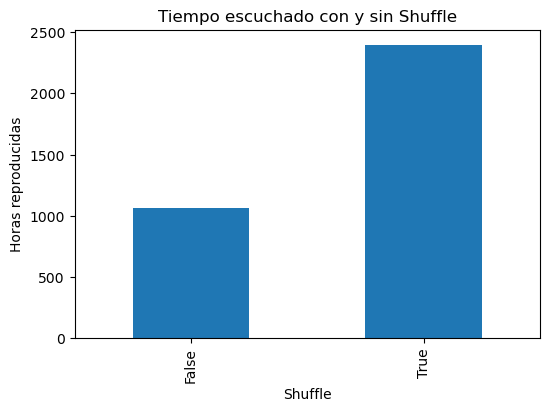

In [19]:
shuffle_tiempo = canciones.groupby("shuffle")["ms_played"].sum()

shuffle_tiempo = shuffle_tiempo / (1000 * 60 * 60)

plt.figure(figsize=(6,4))
shuffle_tiempo.plot(kind="bar")

plt.title("Tiempo escuchado con y sin Shuffle")
plt.xlabel("Shuffle")
plt.ylabel("Horas reproducidas")

plt.show()

# con groupby combino el shuffle con el tiempo que se reprodujo la canción
# con sum saco el tiempo total que se reprodujo con y sin shuffle



In [20]:
canciones["dia_semana"] = canciones["ts"].dt.day_name()

dias = canciones.groupby("dia_semana")["ms_played"].sum()

print("Día con más reproducciones:")
print(dias.idxmax())

# con dt.day_name saco el nombre del día de la semana
# con groupby combino el día de la semana con el tiempo que se reprodujo la canción
# con sum saco el tiempo total que se reprodujo cada día de la semana

Día con más reproducciones:
Saturday


C:\Users\50030868\AppData\Local\Temp\ipykernel_7196\3758217920.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  canciones["dia_semana"] = canciones["ts"].dt.day_name()


In [21]:
canciones["mes"] = canciones["ts"].dt.month_name()

meses = canciones.groupby("mes")["ms_played"].sum()

print("Mes con más reproducciones:")
print(meses.idxmax())

# con dt.month_name saco el nombre del mes
# con groupby combino el mes con el tiempo que se reprodujo la canción
# con sum saco el tiempo total que se reprodujo cada mes

C:\Users\50030868\AppData\Local\Temp\ipykernel_7196\2858776766.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  canciones["mes"] = canciones["ts"].dt.month_name()


Mes con más reproducciones:
July


In [22]:
saltadas = canciones[canciones["skipped"] == True]

cancion_mas_salteada = saltadas.groupby(
    "master_metadata_track_name"
).size()

print("Canción más salteada:")
print(cancion_mas_salteada.idxmax())
print(cancion_mas_salteada.max())

# filtro las canciones que se saltaron
# con groupby combino la canción con el número de veces que se saltó

Canción más salteada:
On The Sunny Side Of The Street
22


In [23]:
!pip install spotipy --upgrade

Defaulting to user installation because normal site-packages is not writeable


In [24]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

sp = spotipy.Spotify(
    auth_manager=SpotifyClientCredentials(
        client_id="e81888285f8a4963a6f4103a635c033b",
        client_secret="46414f738bc24a6b9a632a707cf572d7"
    )
)
